# Loss plots from Lightning logs

`logs/lightning_logs/version_*` 안의 TensorBoard event 파일을 읽어서 loss 그래프를 그립니다.

필요 패키지: `tensorboard`, `pandas`, `matplotlib`

In [1]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt

try:
    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "tensorboard 패키지가 필요합니다. 노트북에서 `!pip install tensorboard`를 한 번 실행한 뒤 다시 실행해주세요."
    ) from exc

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 200)

ROOT = Path.cwd()
LOG_DIR = ROOT / "logs" / "lightning_logs"

if not LOG_DIR.exists():
    raise FileNotFoundError(f"로그 폴더를 찾을 수 없습니다: {LOG_DIR}")

def version_number(path: Path) -> int:
    match = re.search(r"version_(\d+)$", path.name)
    return int(match.group(1)) if match else -1

versions = sorted(LOG_DIR.glob("version_*"), key=version_number)
versions

[PosixPath('/home/carol/chaeyeon-kim/alpha26/logs/lightning_logs/version_0'),
 PosixPath('/home/carol/chaeyeon-kim/alpha26/logs/lightning_logs/version_1'),
 PosixPath('/home/carol/chaeyeon-kim/alpha26/logs/lightning_logs/version_2'),
 PosixPath('/home/carol/chaeyeon-kim/alpha26/logs/lightning_logs/version_3'),
 PosixPath('/home/carol/chaeyeon-kim/alpha26/logs/lightning_logs/version_4'),
 PosixPath('/home/carol/chaeyeon-kim/alpha26/logs/lightning_logs/version_5'),
 PosixPath('/home/carol/chaeyeon-kim/alpha26/logs/lightning_logs/version_6'),
 PosixPath('/home/carol/chaeyeon-kim/alpha26/logs/lightning_logs/version_7'),
 PosixPath('/home/carol/chaeyeon-kim/alpha26/logs/lightning_logs/version_8'),
 PosixPath('/home/carol/chaeyeon-kim/alpha26/logs/lightning_logs/version_9'),
 PosixPath('/home/carol/chaeyeon-kim/alpha26/logs/lightning_logs/version_10')]

In [2]:
rows = []
tag_summary = []

for version_dir in versions:
    event_files = sorted(version_dir.glob("events.out.tfevents.*"))
    if not event_files:
        continue

    accumulator = EventAccumulator(str(version_dir), size_guidance={"scalars": 0})
    accumulator.Reload()

    scalar_tags = sorted(accumulator.Tags().get("scalars", []))
    tag_summary.append(
        {
            "version": version_dir.name,
            "num_event_files": len(event_files),
            "num_scalar_tags": len(scalar_tags),
            "scalar_tags": ", ".join(scalar_tags),
        }
    )

    for tag in scalar_tags:
        for event in accumulator.Scalars(tag):
            rows.append(
                {
                    "version": version_dir.name,
                    "version_num": version_number(version_dir),
                    "tag": tag,
                    "step": event.step,
                    "wall_time": event.wall_time,
                    "value": event.value,
                }
            )

df = pd.DataFrame(rows)
tag_df = pd.DataFrame(tag_summary)

if df.empty:
    raise ValueError(f"TensorBoard scalar를 찾지 못했습니다: {LOG_DIR}")

loss_tags = sorted(tag for tag in df["tag"].unique() if "loss" in tag.lower())
if not loss_tags:
    loss_tags = sorted(df["tag"].unique())

print(f"loaded rows: {len(df):,}")
print("loss tags:", loss_tags)
display(tag_df[["version", "num_event_files", "num_scalar_tags", "scalar_tags"]])
display(df.head())

loaded rows: 114,884
loss tags: ['train_loss_epoch', 'train_loss_step', 'val_loss']


,version,num_event_files,num_scalar_tags,scalar_tags
0,version_0,1,2,"hp_metric, lr-AdamW"
1,version_1,1,2,"hp_metric, lr-AdamW"
2,version_2,1,19,"epoch, hp_metric, lr-AdamW, train_lidar_depth_..."
3,version_3,1,19,"epoch, hp_metric, lr-AdamW, train_lidar_depth_..."
4,version_4,1,19,"epoch, hp_metric, lr-AdamW, train_lidar_depth_..."
5,version_5,1,2,"hp_metric, lr-AdamW"
6,version_6,1,2,"hp_metric, lr-AdamW"
7,version_7,1,19,"epoch, hp_metric, lr-AdamW, train_lidar_depth_..."
8,version_8,1,11,"epoch, hp_metric, lr-AdamW, train_lidar_depth_..."
9,version_9,1,27,"epoch, hp_metric, lr-AdamW, train_lidar_depth_..."


,version,version_num,tag,step,wall_time,value
0,version_0,0,hp_metric,0,1.777539e+09,-1.0000
1,version_0,0,lr-AdamW,0,1.777539e+09,0.0001
2,version_1,1,hp_metric,0,1.777540e+09,-1.0000
3,version_1,1,lr-AdamW,0,1.777540e+09,0.0001
4,version_2,2,epoch,9,1.777540e+09,0.0000


## 전체 version의 main loss 비교

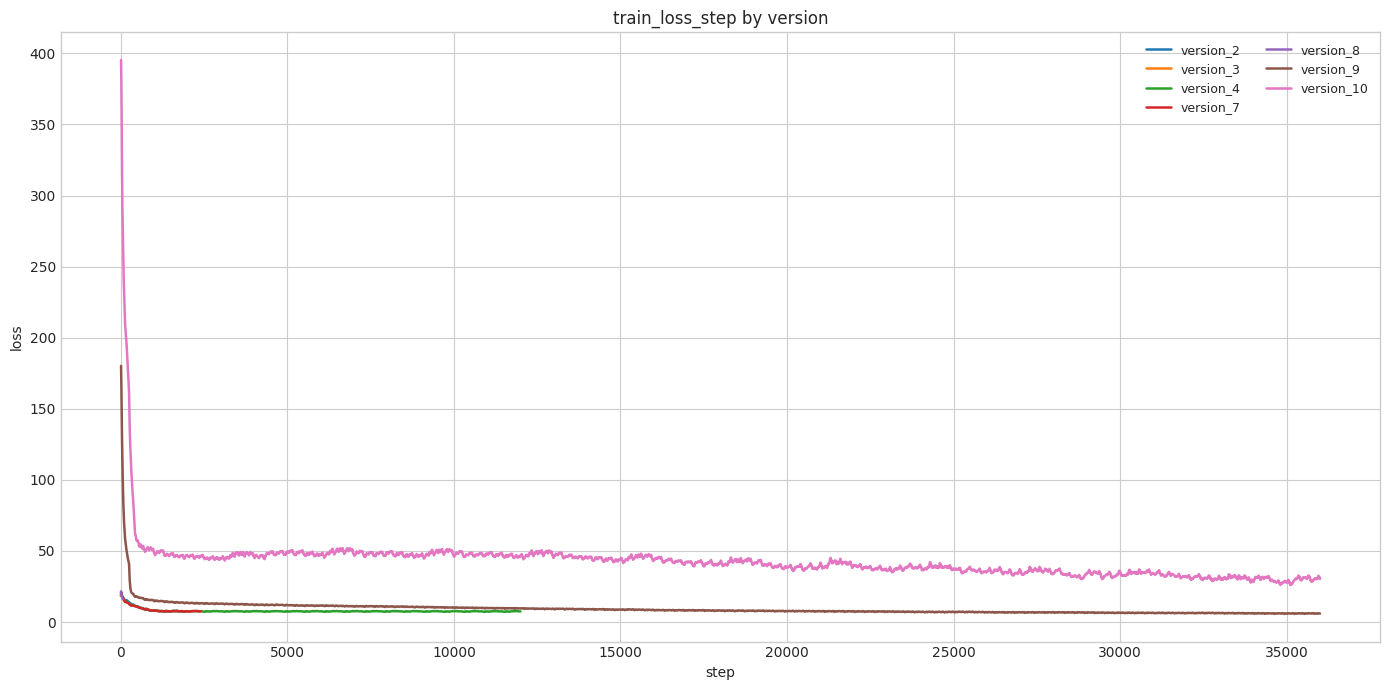

In [3]:
MAIN_LOSS_TAG = "train_loss_step" if "train_loss_step" in set(df["tag"]) else loss_tags[0]
SMOOTH_WINDOW = 25

plot_df = df[df["tag"].eq(MAIN_LOSS_TAG)].copy()
plot_df = plot_df.sort_values(["version_num", "step"])
plot_df["smoothed"] = plot_df.groupby("version")["value"].transform(
    lambda s: s.rolling(SMOOTH_WINDOW, min_periods=1).mean()
)

fig, ax = plt.subplots(figsize=(14, 7))
for version, group in plot_df.groupby("version", sort=False):
    ax.plot(group["step"], group["smoothed"], label=version, linewidth=1.8)

ax.set_title(f"{MAIN_LOSS_TAG} by version")
ax.set_xlabel("step")
ax.set_ylabel("loss")
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

## 최신 version의 loss component 보기

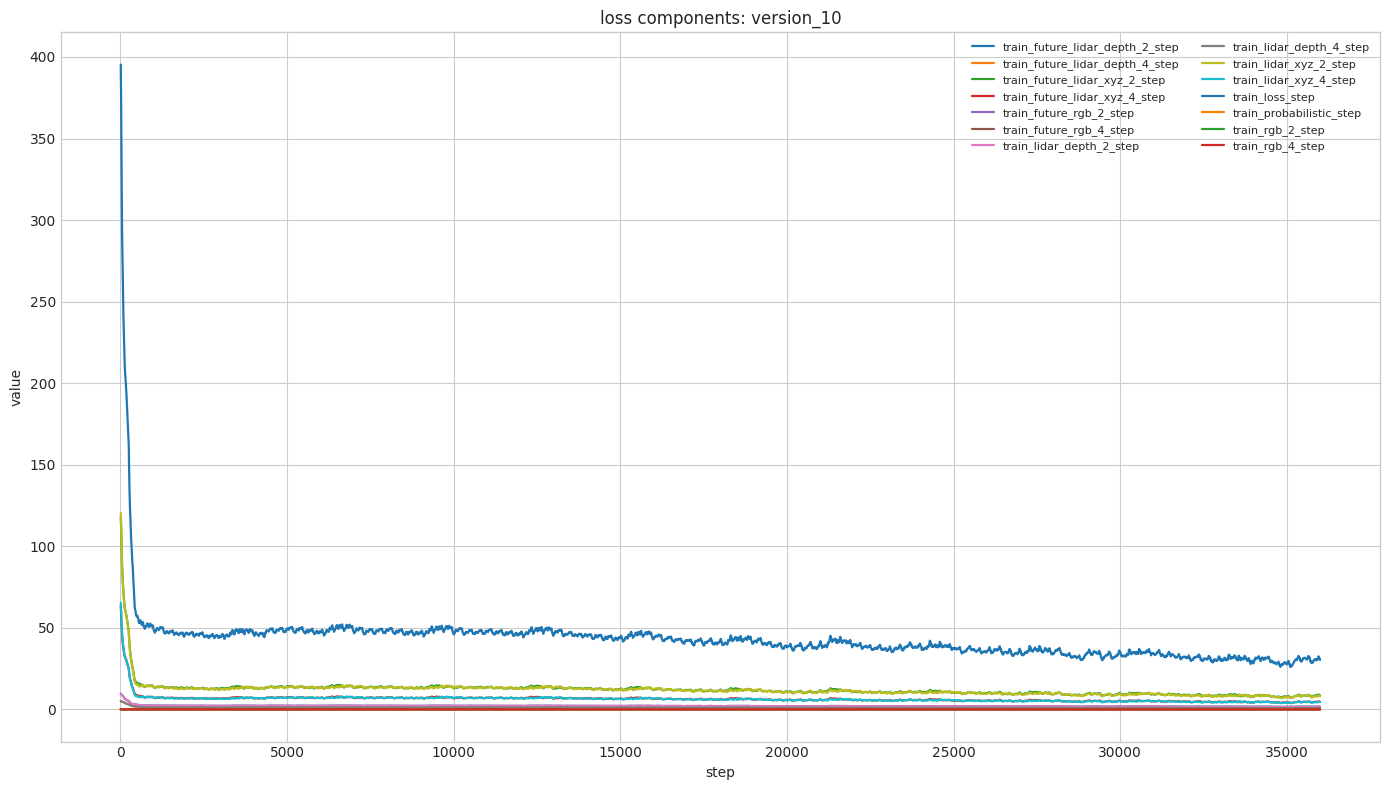

In [4]:
LATEST_VERSION = f"version_{df['version_num'].max()}"
COMPONENT_TAGS = [
    tag for tag in sorted(df["tag"].unique())
    if tag.startswith("train_") and tag.endswith("_step")
]
SMOOTH_WINDOW = 25

plot_df = df[df["version"].eq(LATEST_VERSION) & df["tag"].isin(COMPONENT_TAGS)].copy()
plot_df = plot_df.sort_values(["tag", "step"])
plot_df["smoothed"] = plot_df.groupby("tag")["value"].transform(
    lambda s: s.rolling(SMOOTH_WINDOW, min_periods=1).mean()
)

fig, ax = plt.subplots(figsize=(14, 8))
for tag, group in plot_df.groupby("tag", sort=True):
    ax.plot(group["step"], group["smoothed"], label=tag, linewidth=1.6)

ax.set_title(f"loss components: {LATEST_VERSION}")
ax.set_xlabel("step")
ax.set_ylabel("value")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## 원하는 태그만 골라 그리기

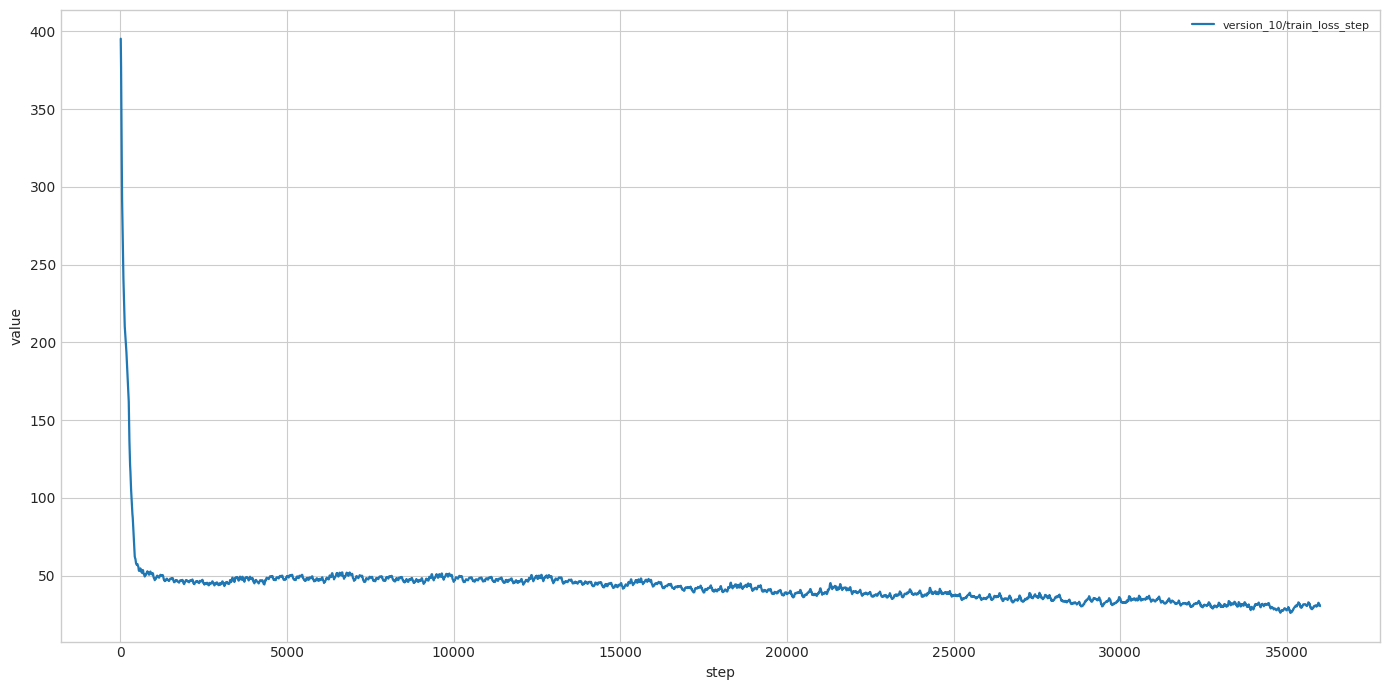

In [5]:
def plot_loss(tags=None, version_names=None, smooth_window=25, figsize=(14, 7)):
    tags = tags or loss_tags
    version_names = version_names or sorted(df["version"].unique(), key=lambda name: int(name.split("_")[-1]))

    plot_df = df[df["tag"].isin(tags) & df["version"].isin(version_names)].copy()
    plot_df = plot_df.sort_values(["version_num", "tag", "step"])
    plot_df["smoothed"] = plot_df.groupby(["version", "tag"])["value"].transform(
        lambda s: s.rolling(smooth_window, min_periods=1).mean()
    )

    fig, ax = plt.subplots(figsize=figsize)
    for (version, tag), group in plot_df.groupby(["version", "tag"], sort=False):
        label = f"{version}/{tag}"
        ax.plot(group["step"], group["smoothed"], label=label, linewidth=1.6)

    ax.set_xlabel("step")
    ax.set_ylabel("value")
    ax.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

# 예시: 최신 version의 main loss만 보기
plot_loss(tags=[MAIN_LOSS_TAG], version_names=[LATEST_VERSION], smooth_window=25)